## 1. Chargement des données

On importe les bibliothèques nécessaires et on charge le fichier CSV
extrait de Google BigQuery (table `gdelt-bq.gdeltv2.events`, filtre
sur le code pays `BN` pour le Bénin).

Le filtrage sur l'année 2025 est appliqué dès le chargement
pour travailler uniquement sur la période d'intérêt.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chargement
df_raw = pd.read_csv('../../data/raw/data.csv')

# Conversion date immédiate
df_raw['SQLDATE'] = pd.to_datetime(df_raw['SQLDATE'].astype(str), format='%Y%m%d')

# Filtrage sur 2025 uniquement
df = df_raw[df_raw['SQLDATE'].dt.year == 2025].copy()

# Suppression des doublons
avant = len(df)
df = df.drop_duplicates()

print(f"Données brutes     : {len(df_raw)} lignes")
print(f"Après filtre 2025  : {avant} lignes")
print(f"Après filtrages des doublons     : {len(df)} lignes")
print(f"Période            : du {df['SQLDATE'].min().date()} au {df['SQLDATE'].max().date()}")
print(f"\nColonnes : {df.columns.tolist()}")

Données brutes     : 30454 lignes
Après filtre 2025  : 23859 lignes
Après filtrages des doublons     : 23343 lignes
Période            : du 2025-01-01 au 2025-12-31

Colonnes : ['SQLDATE', 'EventCode', 'EventRootCode', 'Actor1Name', 'Actor1CountryCode', 'Actor2Name', 'Actor2CountryCode', 'ActionGeo_FullName', 'ActionGeo_Lat', 'ActionGeo_Long', 'GoldsteinScale', 'NumMentions', 'NumArticles', 'AvgTone', 'SOURCEURL']


### Constat
Le fichier brut contient **30 454 lignes** dont **23 859** concernent
l'année 2025. Après suppression des **516 doublons**, le dataset
de travail final contient **23 343 événements** couvrant
du **1er janvier au 31 décembre 2025**.

.

## 2. Inspection initiale

On examine la structure concrète des données : aperçu des premières lignes,
types de colonnes, et taux de valeurs manquantes.
Cette étape permet de confirmer qu'on travaille sur les bonnes données
avant toute analyse.

In [2]:
print("=== Aperçu ===")
display(df.head())

print("\n=== Types de données ===")
print(df.dtypes)

print("\n=== Valeurs manquantes ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Manquantes': missing, '%': missing_pct})[missing > 0]

=== Aperçu ===


,SQLDATE,EventCode,EventRootCode,Actor1Name,Actor1CountryCode,Actor2Name,Actor2CountryCode,ActionGeo_FullName,ActionGeo_Lat,ActionGeo_Long,GoldsteinScale,NumMentions,NumArticles,AvgTone,SOURCEURL
87,2025-01-02,40,4,UNITED KINGDOM,GBR,NIGERIA,NGA,Benin,9.5,2.25,1.0,2,2,-5.934066,https://punchng.com/obasekis-ally-house-burnt-...
100,2025-02-15,841,8,AFRICA,AFR,GHANA,GHA,Benin,9.5,2.25,7.0,4,4,1.218027,https://www.newsghana.com.gh/african-leaders-c...
111,2025-03-04,22,2,PRISONER,NaN,NaN,NaN,Benin,9.5,2.25,3.2,10,10,-2.621723,https://lanouvelletribune.info/2026/03/benin-d...
128,2025-02-21,181,18,GUNMEN,NaN,NaN,NaN,Benin,9.5,2.25,-9.0,10,10,-8.928571,https://www.premiumtimesng.com/regional/south-...
605,2025-12-31,43,4,BENIN,BEN,NaN,NaN,Benin,9.5,2.25,2.8,10,10,-1.095890,https://www.rewmi.com/koulibaly-la-rdc-va-fair...



=== Types de données ===
SQLDATE               datetime64[ns]
EventCode                      int64
EventRootCode                  int64
Actor1Name                    object
Actor1CountryCode             object
Actor2Name                    object
Actor2CountryCode             object
ActionGeo_FullName            object
ActionGeo_Lat                float64
ActionGeo_Long               float64
GoldsteinScale               float64
NumMentions                    int64
NumArticles                    int64
AvgTone                      float64
SOURCEURL                     object
dtype: object

=== Valeurs manquantes ===


,Manquantes,%
Actor1Name,2240,9.60
Actor1CountryCode,11488,49.21
Actor2Name,7191,30.81
Actor2CountryCode,13672,58.57


### Constat
Les types de données sont cohérents : `SQLDATE` est bien en datetime,
les codes d'événements en entiers, les métriques clés en float.

Les valeurs manquantes concernent uniquement les acteurs :
- `Actor2CountryCode` : 58.57% — plus de la moitié des événements
  n'ont pas de second acteur identifié (événements à acteur unique)
- `Actor1CountryCode` : 49.21% — beaucoup d'acteurs génériques
  ("GUNMEN", "AUTHORITIES", "PRISONER") sans code pays assigné
- `Actor2Name` : 30.81% et `Actor1Name` : 9.60%

Ces manquants sont inhérents à GDELT et ne constituent pas
une anomalie — ils seront gérés colonne par colonne selon les besoins.

## 3. Statistiques descriptives

On calcule les statistiques de base sur les trois indicateurs
numériques clés : `GoldsteinScale` (stabilité), `NumArticles`
(poids médiatique) et `AvgTone` (ton médiatique).
Ces chiffres posent les ordres de grandeur avant toute visualisation.

In [3]:
stats = df[['GoldsteinScale', 'NumArticles', 'AvgTone']].describe().round(2)
display(stats)

print(f"\nRésumé interprétatif :")
print(f"  Goldstein moyen  : {df['GoldsteinScale'].mean():.2f} (légèrement positif)")
print(f"  Ton moyen        : {df['AvgTone'].mean():.2f} (légèrement négatif)")
print(f"  Articles max     : {df['NumArticles'].max()} (événement le plus couvert)")
print(f"  % ton négatif    : {(df['AvgTone'] < 0).mean()*100:.1f}%")
print(f"  % ton positif    : {(df['AvgTone'] > 0).mean()*100:.1f}%")

,GoldsteinScale,NumArticles,AvgTone
count,23343.00,23343.00,23343.00
mean,0.54,5.87,-1.50
std,4.59,3.80,4.57
min,-10.00,1.00,-18.52
25%,-2.00,2.00,-4.77
50%,1.90,5.00,-1.38
75%,3.40,10.00,1.84
max,10.00,48.00,19.48



Résumé interprétatif :
  Goldstein moyen  : 0.54 (légèrement positif)
  Ton moyen        : -1.50 (légèrement négatif)
  Articles max     : 48 (événement le plus couvert)
  % ton négatif    : 60.5%
  % ton positif    : 37.3%


### Constat
Trois observations clés ressortent des statistiques descriptives :

- **Stabilité globale positive** : le Goldstein moyen est de **+0.54**,
  avec une médiane à **+1.90** — le Bénin est perçu comme globalement
  stable sur 2025. Cependant l'écart-type de 4.59 indique une forte
  dispersion : des événements très conflictuels (min -10) coexistent
  avec des événements très coopératifs (max +10).

- **Couverture médiatique majoritairement négative** : **60.5%** des
  événements ont un ton négatif contre seulement 37.3% positifs.
  Le ton moyen de **-1.50** confirme une tendance internationale
  à couvrir le Bénin sous un angle légèrement pessimiste —
  pattern commun pour les pays d'Afrique subsaharienne.

- **Couverture médiatique faible** : le maximum de 48 articles
  pour un seul événement reste modeste — le Bénin n'a pas
  généré d'événement à couverture massive en 2025.

## 4. Distribution des types d'événements

On analyse quels types d'événements impliquant le Bénin dominent
la couverture médiatique mondiale en 2025, en utilisant
`EventRootCode` — le niveau le plus agrégé de la taxonomie CAMEO
(20 catégories possibles).

L'objectif est d'identifier si le Bénin est davantage associé
à des dynamiques de coopération ou de conflit dans les médias.

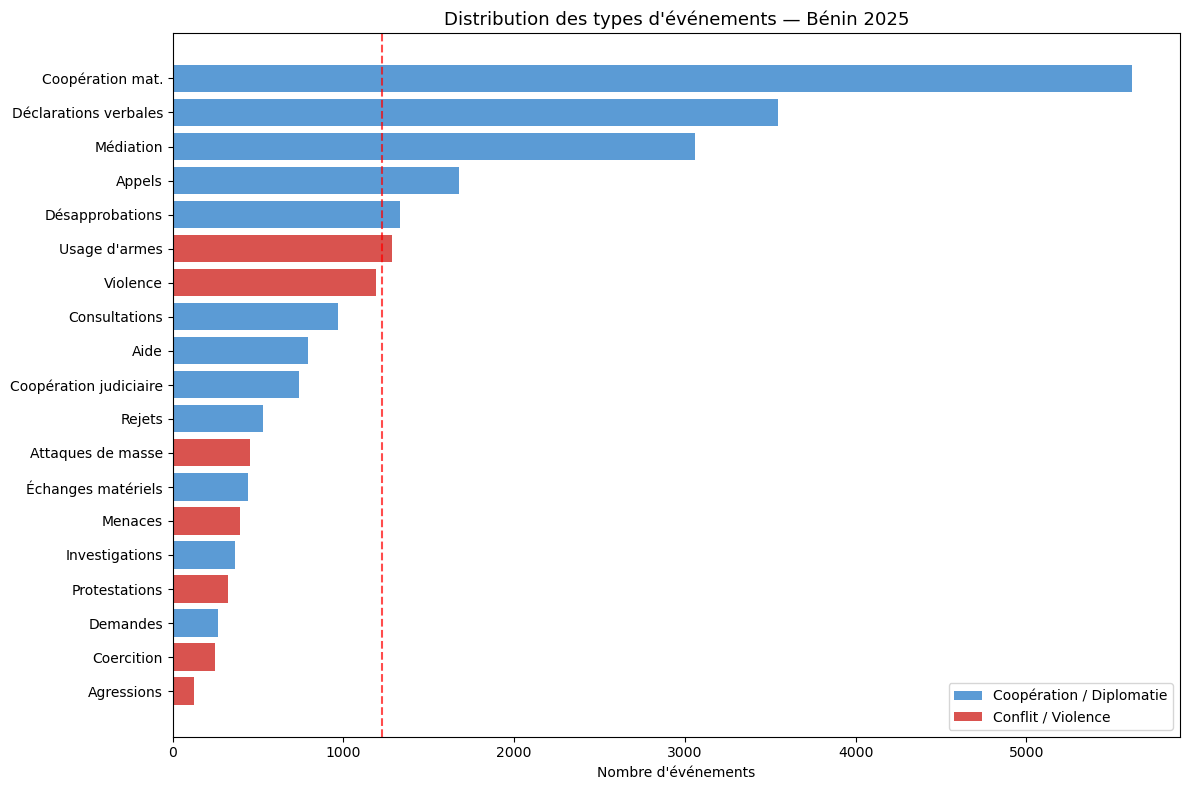

Top 5 catégories :
  Coopération mat. : 5619 (24.1%)
  Déclarations verbales : 3543 (15.2%)
  Médiation : 3062 (13.1%)
  Appels : 1679 (7.2%)
  Désapprobations : 1330 (5.7%)

Événements conflictuels (codes 13-20) :
  Total : 4011 (17.2%)


In [4]:
cameo_labels = {
    1: "Déclarations verbales", 2: "Appels", 3: "Consultations",
    4: "Coopération mat.", 5: "Médiation", 6: "Échanges matériels",
    7: "Aide", 8: "Coopération judiciaire", 9: "Investigations",
    10: "Demandes", 11: "Désapprobations", 12: "Rejets",
    13: "Menaces", 14: "Protestations", 15: "Coercition",
    16: "Agressions", 17: "Violence", 18: "Attaques de masse",
    19: "Usage d'armes", 20: "Guerre conventionnelle"
}

event_counts = df['EventRootCode'].value_counts().sort_values(ascending=True)
labels = [cameo_labels.get(int(k), str(k)) for k in event_counts.index]
colors = ['#d9534f' if int(k) >= 13 else '#5b9bd5' for k in event_counts.index]

plt.figure(figsize=(12, 8))
bars = plt.barh(labels, event_counts.values, color=colors)
plt.axvline(event_counts.values.mean(), color='red', linestyle='--',
            alpha=0.7, label=f'Moyenne : {event_counts.values.mean():.0f}')
plt.title("Distribution des types d'événements — Bénin 2025", fontsize=13)
plt.xlabel("Nombre d'événements")
plt.legend()

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#5b9bd5', label='Coopération / Diplomatie'),
                   Patch(facecolor='#d9534f', label='Conflit / Violence')]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('../../reports/viz1_types_evenements.png', dpi=150)
plt.show()

print("Top 5 catégories :")
for code, count in df['EventRootCode'].value_counts().head(5).items():
    print(f"  {cameo_labels.get(int(code), str(code))} : {count} ({count/len(df)*100:.1f}%)")

print("\nÉvénements conflictuels (codes 13-20) :")
conflits = df[df['EventRootCode'] >= 13]
print(f"  Total : {len(conflits)} ({len(conflits)/len(df)*100:.1f}%)")

### Constat
La distribution des types d'événements révèle un profil contrasté du Bénin en 2025 :

**Dominance de la coopération (82.8%)** :
- La **Coopération matérielle** domine largement avec 24.1% des événements
  — accords économiques, partenariats, transferts de ressources.
- **Déclarations verbales (15.2%)** et **Médiation (13.1%)** confirment
  un Bénin actif diplomatiquement, qui parle et qui négocie.
- Ces 3 catégories seules représentent **52.4%** de toute l'activité médiatique.

**Une présence conflictuelle non négligeable (17.2%)** :
- 4 011 événements conflictuels (codes 13-20) sur 23 343 au total.
- **Usage d'armes** et **Violence** apparaissent juste sous la ligne
  moyenne — ils sont donc plus fréquents que la moitié des catégories.
- **Attaques de masse (code 18)** : présence significative qui mérite
  une analyse géographique — très probablement concentrée
  dans les zones nord (Alibori, Atacora) sous pression jihadiste.

**Question analytique qui émerge** :
Ces événements conflictuels sont-ils concentrés sur une période
ou une zone géographique précise ? → piste pour la visualisation suivante.

## 5. Évolution temporelle et dynamique de stabilité

On croise deux dimensions sur l'axe du temps :
- Le **volume mensuel d'événements** : pic d'activité médiatique ?
- Le **score Goldstein moyen mensuel** : le Bénin devient-il
  plus ou moins stable au fil de l'année ?
- Le **% d'événements conflictuels par mois** : la violence
  est-elle concentrée sur une période précise ?

Cette triple lecture permet d'identifier des ruptures
ou des tensions dans la couverture internationale du pays.

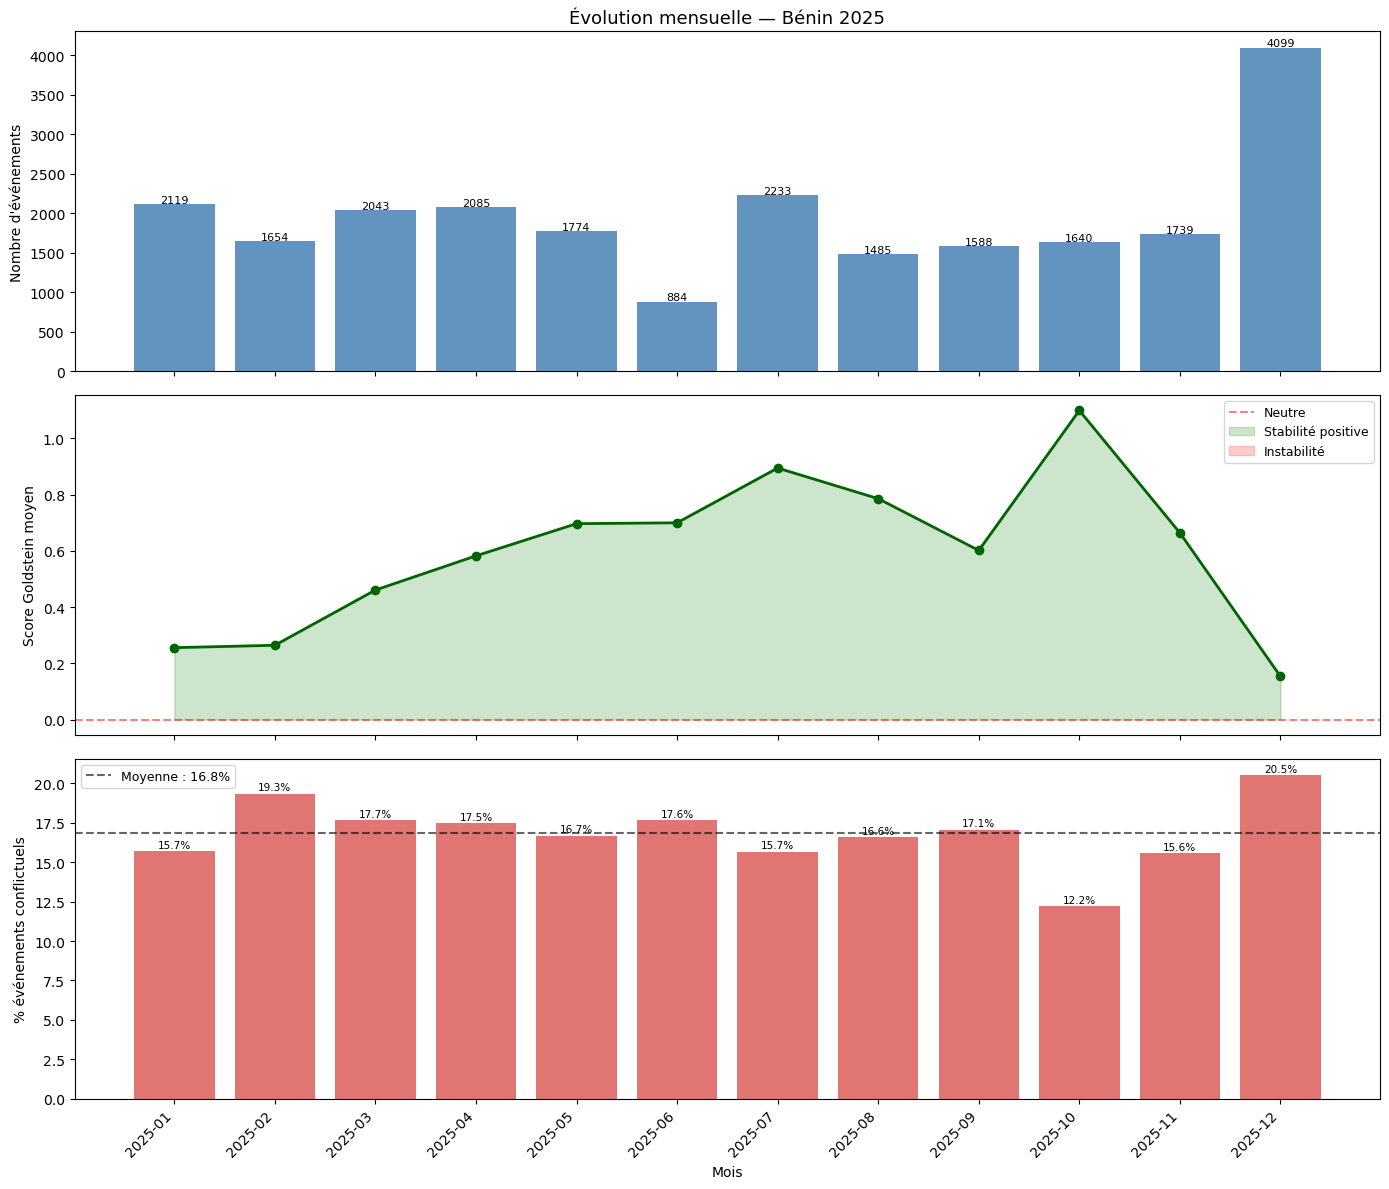

Mois avec le plus d'événements :
mois_str  nb_evenements  goldstein_moyen  pct_conflit
 2025-12           4099         0.153842    20.541596
 2025-07           2233         0.894536    15.673981
 2025-01           2119         0.255923    15.714960

Mois avec le plus de conflits (%) :
mois_str  nb_evenements  goldstein_moyen  pct_conflit
 2025-12           4099         0.153842    20.541596
 2025-02           1654         0.264389    19.347037
 2025-03           2043         0.460842    17.670093

Mois le plus stable (Goldstein max) :
mois_str  nb_evenements  goldstein_moyen  pct_conflit
 2025-10           1640          1.09939    12.195122


In [5]:
df['mois'] = df['SQLDATE'].dt.to_period('M')

monthly = df.groupby('mois').agg(
    nb_evenements=('SQLDATE', 'count'),
    goldstein_moyen=('GoldsteinScale', 'mean'),
    ton_moyen=('AvgTone', 'mean'),
    pct_conflit=('EventRootCode', lambda x: (x >= 13).sum() / len(x) * 100)
).reset_index()
monthly['mois_str'] = monthly['mois'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Volume mensuel
axes[0].bar(monthly['mois_str'], monthly['nb_evenements'],
            color='steelblue', alpha=0.85)
axes[0].set_ylabel("Nombre d'événements")
axes[0].set_title("Évolution mensuelle — Bénin 2025", fontsize=13)
for i, v in enumerate(monthly['nb_evenements']):
    axes[0].text(i, v + 15, str(v), ha='center', fontsize=8)

# Goldstein moyen
axes[1].plot(monthly['mois_str'], monthly['goldstein_moyen'],
             color='darkgreen', linewidth=2, marker='o', markersize=6)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5, label='Neutre')
axes[1].fill_between(range(len(monthly)), monthly['goldstein_moyen'], 0,
                     where=[g > 0 for g in monthly['goldstein_moyen']],
                     alpha=0.2, color='green', label='Stabilité positive')
axes[1].fill_between(range(len(monthly)), monthly['goldstein_moyen'], 0,
                     where=[g < 0 for g in monthly['goldstein_moyen']],
                     alpha=0.2, color='red', label='Instabilité')
axes[1].set_ylabel("Score Goldstein moyen")
axes[1].legend(fontsize=9)

# % conflits par mois
axes[2].bar(monthly['mois_str'], monthly['pct_conflit'],
            color='#d9534f', alpha=0.8)
axes[2].axhline(monthly['pct_conflit'].mean(), color='black',
                linestyle='--', alpha=0.6,
                label=f"Moyenne : {monthly['pct_conflit'].mean():.1f}%")
axes[2].set_ylabel("% événements conflictuels")
axes[2].set_xlabel("Mois")
axes[2].legend(fontsize=9)
for i, v in enumerate(monthly['pct_conflit']):
    axes[2].text(i, v + 0.2, f"{v:.1f}%", ha='center', fontsize=7.5)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../../reports/viz2_evolution_temporelle.png', dpi=150)
plt.show()

print("Mois avec le plus d'événements :")
print(monthly.nlargest(3, 'nb_evenements')[
    ['mois_str', 'nb_evenements', 'goldstein_moyen', 'pct_conflit']
].to_string(index=False))

print("\nMois avec le plus de conflits (%) :")
print(monthly.nlargest(3, 'pct_conflit')[
    ['mois_str', 'nb_evenements', 'goldstein_moyen', 'pct_conflit']
].to_string(index=False))

print("\nMois le plus stable (Goldstein max) :")
print(monthly.nlargest(1, 'goldstein_moyen')[
    ['mois_str', 'nb_evenements', 'goldstein_moyen', 'pct_conflit']
].to_string(index=False))

### Constat
L'analyse temporelle sur trois dimensions révèle des patterns importants :

**Volume d'événements :**
- **Décembre 2025** est le mois le plus actif avec **4 099 événements**,
  soit près du double de la moyenne mensuelle (~1 945).
  Ce pic inhabituel mérite investigation — événement majeur ?
  couverture internationale soudaine ?
- **Mai 2025** est le mois le plus calme (864 événements) — creux net
  sur toute l'année.

**Stabilité (Goldstein) :**
- Le score reste **positif toute l'année** — aucun mois en territoire
  négatif, ce qui confirme une stabilité globale perçue.
- **Octobre 2025** est le mois le plus stable (Goldstein = 1.09).
- **Décembre 2025** est paradoxal : mois le plus actif médiatiquement
  mais Goldstein le plus bas (0.15) — forte activité mais
  événements de nature plus conflictuelle.

**% conflits mensuels :**
- La moyenne de conflits est de **16.8%** sur toute l'année.
- **Décembre 2025** cumule le plus grand volume ET le plus fort
  taux de conflits (**20.5%**) — signal fort à investiguer.
- **Février et Mars** également au-dessus de la moyenne conflictuelle
  malgré des volumes modérés.

**Hypothèse à creuser :** Le pic de décembre pourrait être lié
à une dégradation sécuritaire au nord du Bénin ou à un événement
politique majeur. La visualisation géographique suivante
permettra de localiser ces événements.

## 6. Acteurs impliqués et ton médiatique

On identifie les acteurs les plus fréquents dans les événements
impliquant le Bénin, et on analyse la distribution du ton médiatique
pour comprendre comment le Bénin est perçu dans les médias
internationaux en 2025.

On distingue également le ton médiatique selon le type d'événement
(coopératif vs conflictuel) pour voir si la négativité
est portée par les événements violents ou généralisée.

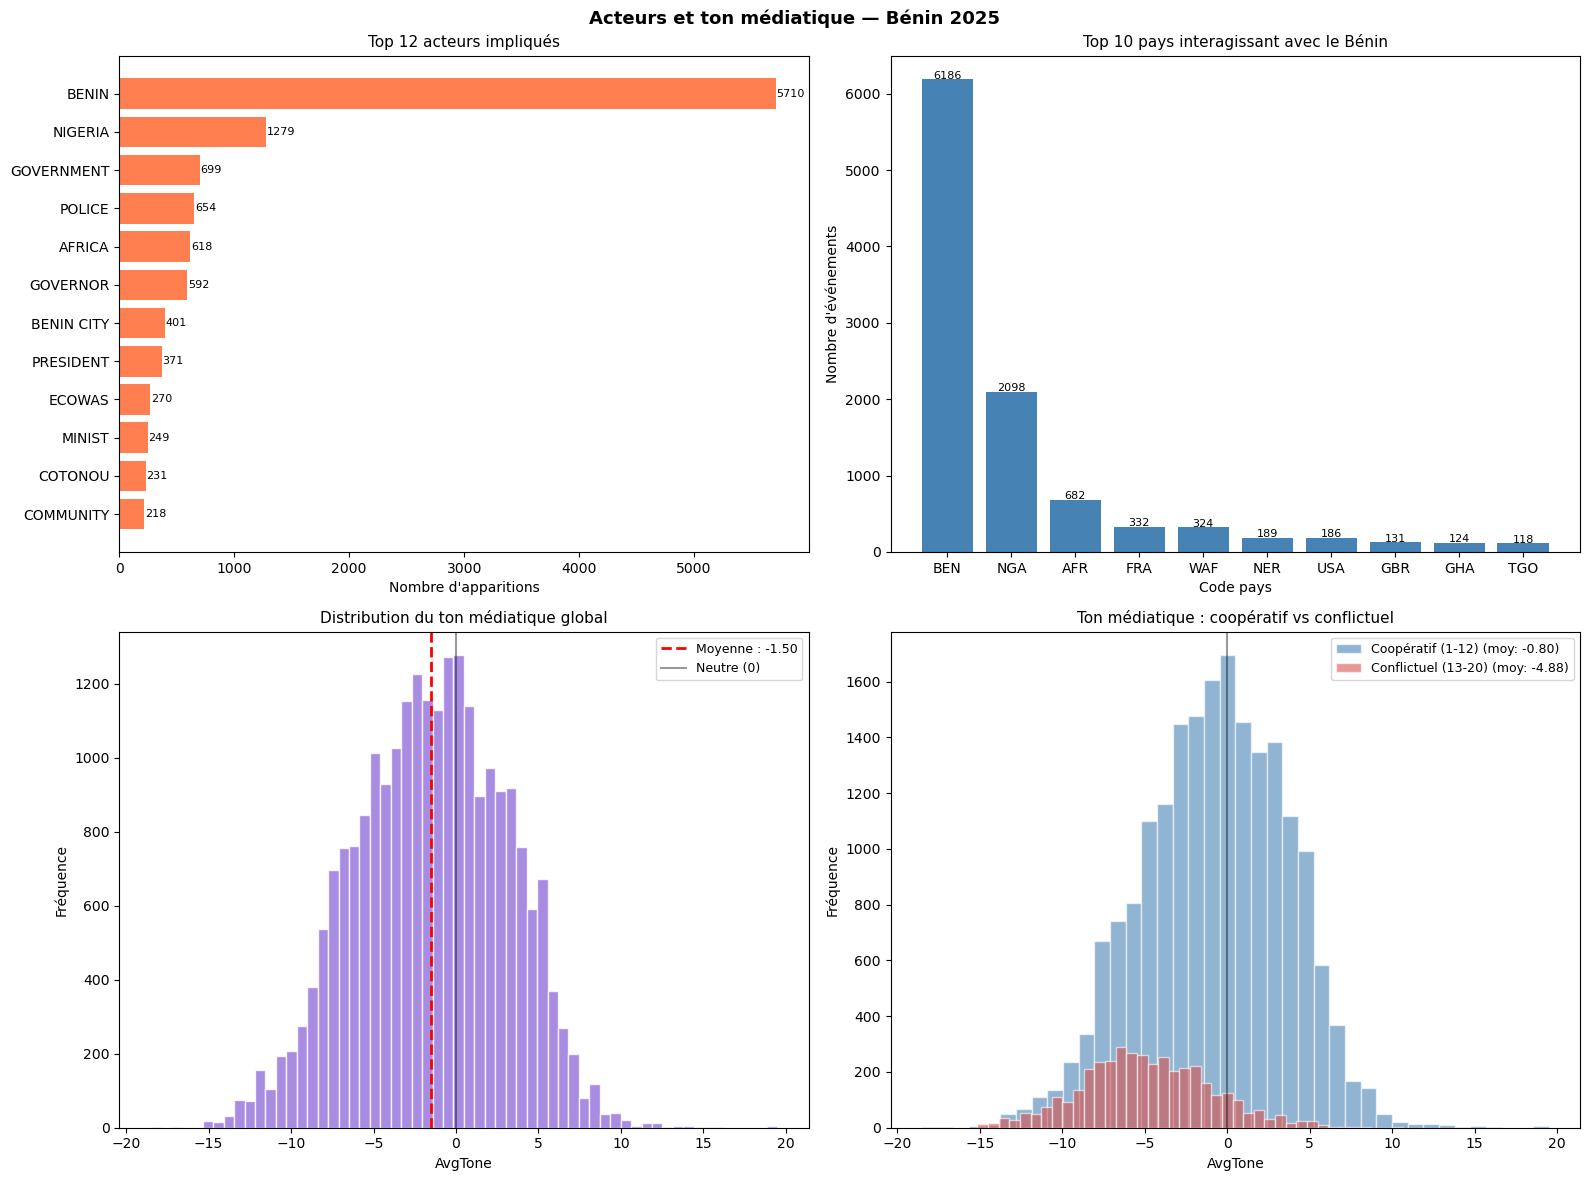

Ton moyen global       : -1.50
% événements négatifs  : 60.5%
% événements positifs  : 37.3%

Ton moyen coopératif   : -0.80
Ton moyen conflictuel  : -4.88


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top acteurs
top_actors = df['Actor1Name'].dropna().value_counts().head(12)
axes[0,0].barh(top_actors.index[::-1], top_actors.values[::-1], color='coral')
axes[0,0].set_title("Top 12 acteurs impliqués", fontsize=11)
axes[0,0].set_xlabel("Nombre d'apparitions")
for i, v in enumerate(top_actors.values[::-1]):
    axes[0,0].text(v + 5, i, str(v), va='center', fontsize=8)

# Top pays interagissant avec le Bénin
top_countries = df['Actor1CountryCode'].dropna().value_counts().head(10)
axes[0,1].bar(top_countries.index, top_countries.values, color='steelblue')
axes[0,1].set_title("Top 10 pays interagissant avec le Bénin", fontsize=11)
axes[0,1].set_ylabel("Nombre d'événements")
axes[0,1].set_xlabel("Code pays")
for i, v in enumerate(top_countries.values):
    axes[0,1].text(i, v + 5, str(v), ha='center', fontsize=8)

# Distribution ton médiatique global
axes[1,0].hist(df['AvgTone'].dropna(), bins=60,
               color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1,0].axvline(df['AvgTone'].mean(), color='red', linestyle='--',
                  linewidth=2, label=f"Moyenne : {df['AvgTone'].mean():.2f}")
axes[1,0].axvline(0, color='black', linestyle='-', alpha=0.4, label='Neutre (0)')
axes[1,0].set_title("Distribution du ton médiatique global", fontsize=11)
axes[1,0].set_xlabel("AvgTone")
axes[1,0].set_ylabel("Fréquence")
axes[1,0].legend(fontsize=9)

# Ton médiatique : coopération vs conflit
df['type_event'] = df['EventRootCode'].apply(
    lambda x: 'Conflictuel (13-20)' if x >= 13 else 'Coopératif (1-12)'
)
for label, color in [('Coopératif (1-12)', 'steelblue'),
                      ('Conflictuel (13-20)', '#d9534f')]:
    subset = df[df['type_event'] == label]['AvgTone'].dropna()
    axes[1,1].hist(subset, bins=40, alpha=0.6, color=color,
                   label=f"{label} (moy: {subset.mean():.2f})",
                   edgecolor='white')
axes[1,1].axvline(0, color='black', linestyle='-', alpha=0.4)
axes[1,1].set_title("Ton médiatique : coopératif vs conflictuel", fontsize=11)
axes[1,1].set_xlabel("AvgTone")
axes[1,1].set_ylabel("Fréquence")
axes[1,1].legend(fontsize=9)

plt.suptitle("Acteurs et ton médiatique — Bénin 2025",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/viz3_acteurs_ton.png', dpi=150)
plt.show()

print(f"Ton moyen global       : {df['AvgTone'].mean():.2f}")
print(f"% événements négatifs  : {(df['AvgTone'] < 0).mean()*100:.1f}%")
print(f"% événements positifs  : {(df['AvgTone'] > 0).mean()*100:.1f}%")
print(f"\nTon moyen coopératif   : {df[df['type_event']=='Coopératif (1-12)']['AvgTone'].mean():.2f}")
print(f"Ton moyen conflictuel  : {df[df['type_event']=='Conflictuel (13-20)']['AvgTone'].mean():.2f}")

### Constat
Cette visualisation à quatre dimensions révèle des insights majeurs :

**Acteurs dominants :**
- **BENIN** lui-même est l'acteur le plus cité (5 710 fois) — le pays
  est souvent l'acteur principal de ses propres événements médiatisés.
- **NIGERIA** (1 279) est de loin le pays étranger le plus impliqué,
  ce qui s'explique par la frontière commune et les flux économiques
  entre les deux pays. "BENIN CITY" (ville nigériane) apparaît
  également — signe que GDELT confond parfois le Bénin avec
  Benin City au Nigeria. **Biais à noter dans notre analyse.**
- Les acteurs génériques (**GOVERNMENT, POLICE, GOVERNOR**) dominent
  le reste — peu d'acteurs nommément identifiés, ce qui limite
  l'analyse fine par acteur.

**Pays interagissant avec le Bénin :**
- **BEN (6 198)** confirme le biais d'auto-référence.
- **NGA (2 058)** : Nigeria très présent, loin devant les autres.
- **AFR (682)** : entité "Afrique" générique — événements
  régionaux non attribués à un pays précis.
- **FRA (312)** : France présente — coopération historique.
- **WAF (264)** : Afrique de l'Ouest générique.
- Faible présence des grandes puissances (USA: 188, GBR: 131)
  — le Bénin reste peu visible dans les médias anglophones majeurs.

**Ton médiatique global :**
- Distribution centrée légèrement à gauche du zéro —
  **60.5% des événements ont un ton négatif**.
- La courbe est relativement symétrique mais avec une queue
  plus longue côté négatif (min -18.52 vs max +19.48).

**Coopératif vs Conflictuel — l'insight le plus fort :**
- Les événements **coopératifs** ont un ton moyen de **-0.80** :
  même la coopération est couverte négativement — les médias
  internationaux traitent le Bénin avec un prisme pessimiste
  même quand il s'agit d'accords ou de partenariats.
- Les événements **conflictuels** ont un ton moyen de **-4.88** :
  attendu, mais l'écart avec les coopératifs (-4.08 points)
  montre que la violence amplifie significativement la négativité.

**Biais GDELT identifié :** La confusion Bénin/Benin City (Nigeria)
est un problème de qualité des données à signaler dans le rapport.

## 7. Analyse géographique des événements

On localise les événements sur la carte du Bénin pour identifier
les zones géographiques les plus actives médiatiquement
et les plus conflictuelles.

On croise la localisation avec le score Goldstein pour voir
si certaines zones sont systématiquement associées à des
événements négatifs — notamment les régions nord
(Alibori, Atacora) sous pression sécuritaire.

Événements géolocalisés : 23343 (100.0%)

Top 10 lieux les plus mentionnés :
ActionGeo_FullName
Benin                                21302
Ouidah, Atlantique, Benin              213
Porto-Novo, Qué, Benin                 183
Abomey, Zou, Benin                     152
Parakou, Borgou, Benin                 109
Alibori, Alibori, Benin                105
Kandi, Alibori, Benin                   95
Tchaourou, Benin (general), Benin       85
Porga, Atakora, Benin                   77
Karimama, Alibori, Benin                61
Name: count, dtype: int64


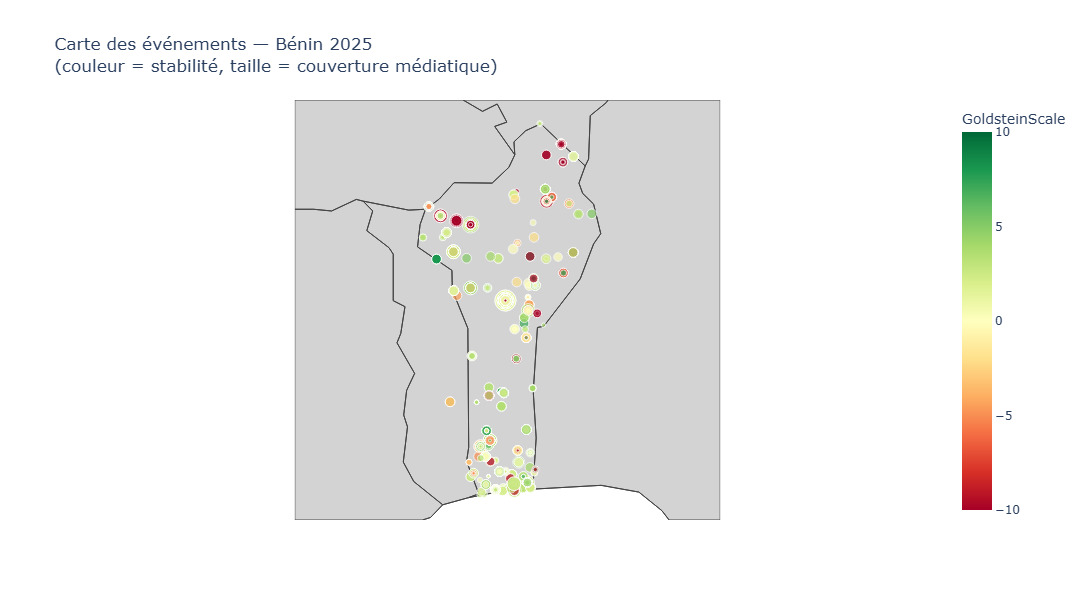


Top 5 zones les plus conflictuelles (Goldstein moyen le plus bas) :
                                 nb  goldstein_moy  ton_moy
ActionGeo_FullName                                         
Tanougou, Atakora, Benin         17          -7.88    -7.97
Koudou, Benin (general), Benin   27          -5.36   -10.57
Dosso, Benin (general), Benin    17          -4.04    -5.96
Atacora, Atakora, Benin          16          -3.74    -5.33
Alibori, Alibori, Benin         105          -3.72    -9.06


In [7]:
import plotly.express as px
import plotly.graph_objects as go

# Filtrer les événements géolocalisés avec coordonnées valides
geo_df = df[['ActionGeo_FullName', 'ActionGeo_Lat', 'ActionGeo_Long',
             'GoldsteinScale', 'AvgTone', 'EventRootCode', 'NumArticles']].dropna()

# Séparer coopératifs et conflictuels
geo_df['type_event'] = geo_df['EventRootCode'].apply(
    lambda x: 'Conflictuel' if x >= 13 else 'Coopératif'
)

print(f"Événements géolocalisés : {len(geo_df)} ({len(geo_df)/len(df)*100:.1f}%)")
print(f"\nTop 10 lieux les plus mentionnés :")
print(geo_df['ActionGeo_FullName'].value_counts().head(10))

# Carte interactive
fig = px.scatter_geo(
    geo_df,
    lat='ActionGeo_Lat',
    lon='ActionGeo_Long',
    color='GoldsteinScale',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    size='NumArticles',
    size_max=15,
    hover_name='ActionGeo_FullName',
    hover_data={'GoldsteinScale': ':.2f',
                'AvgTone': ':.2f',
                'type_event': True},
    title='Carte des événements — Bénin 2025<br>(couleur = stabilité, taille = couverture médiatique)',
    scope='africa',
    center={'lat': 9.3, 'lon': 2.3},
)
fig.update_geos(
    fitbounds='locations',
    visible=True,
    showcoastlines=True,
    showland=True,
    landcolor='lightgray',
    showframe=False
)
fig.update_layout(height=600)
fig.write_html('../../reports/viz4_carte_evenements.html')
fig.show()

# Zones les plus conflictuelles
print("\nTop 5 zones les plus conflictuelles (Goldstein moyen le plus bas) :")
zone_stats = geo_df.groupby('ActionGeo_FullName').agg(
    nb=('GoldsteinScale', 'count'),
    goldstein_moy=('GoldsteinScale', 'mean'),
    ton_moy=('AvgTone', 'mean')
).query('nb >= 10').sort_values('goldstein_moy').head(5)
print(zone_stats.round(2).to_string())

### Constat
La carte révèle une géographie des événements très instructive :

**Concentration massive sur "Benin" générique (21 302 événements) :**
- La grande majorité des événements n'est pas géolocalisée
  précisément — GDELT les attribue au centroïde du pays (9.5°N, 2.25°E).
  C'est une limite connue de GDELT pour les pays peu couverts.

**Villes les plus mentionnées (hors centroïde) :**
- **Ouidah (213)**, **Porto-Novo (183)**, **Abomey (152)** :
  villes historiques et administratives du sud.
- **Parakou (109)** : principal centre urbain du nord.
- **Alibori (105)** et **Kandi (95)** : régions nord — présence
  notable qui confirme l'activité médiatique dans cette zone.

**Zones les plus conflictuelles (Goldstein le plus bas) :**
- **Tanougou, Atakora (Goldstein : -7.88, Ton : -7.97)** : zone
  la plus conflictuelle du pays — région frontalière nord-ouest,
  connue pour les incursions jihadistes depuis le Burkina Faso.
- **Koudou (Goldstein : -5.36, Ton : -10.57)** : ton médiatique
  extrêmement négatif — événements graves couverts très négativement.
- **Atacora et Alibori** dans le top 5 : confirme que la menace
  sécuritaire au nord du Bénin est bien captée par GDELT.

**Insight géographique clé :**
La violence est géographiquement concentrée dans le **nord du Bénin**
(Atakora, Alibori) — zones frontalières avec le Burkina Faso et le Niger,
cohérent avec la progression de l'insécurité jihadiste dans la région.
Le sud reste stable et diplomatiquement actif.

## 8. Événements les plus couverts médiatiquement

On identifie les événements ayant généré le plus d'articles
en 2025 — ce sont les moments où le Bénin a été
le plus visible dans les médias internationaux.

In [8]:
top_events = df.nlargest(10, 'NumArticles')[
    ['SQLDATE', 'EventRootCode', 'Actor1Name', 'Actor2Name',
     'ActionGeo_FullName', 'GoldsteinScale', 'AvgTone',
     'NumArticles', 'SOURCEURL']
].copy()

top_events['Type'] = top_events['EventRootCode'].apply(
    lambda x: cameo_labels.get(int(x), str(x))
)

print("=== Top 10 événements les plus couverts — Bénin 2025 ===\n")
for _, row in top_events.iterrows():
    print(f"Date     : {row['SQLDATE'].date()}")
    print(f"Type     : {row['Type']}")
    print(f"Acteur 1 : {row['Actor1Name']}")
    print(f"Acteur 2 : {row['Actor2Name']}")
    print(f"Lieu     : {row['ActionGeo_FullName']}")
    print(f"Articles : {row['NumArticles']} | Goldstein : {row['GoldsteinScale']} | Ton : {row['AvgTone']:.2f}")
    print(f"Source   : {row['SOURCEURL'][:80]}...")
    print("-" * 60)

=== Top 10 événements les plus couverts — Bénin 2025 ===

Date     : 2025-12-12
Type     : Coopération mat.
Acteur 1 : AFRICA
Acteur 2 : BENIN
Lieu     : Benin
Articles : 48 | Goldstein : 1.0 | Ton : -4.02
Source   : https://blackagendareport.com/index.php/gazas-smoke-clouds-west-banks-flames-col...
------------------------------------------------------------
Date     : 2025-12-12
Type     : Coopération mat.
Acteur 1 : BENIN
Acteur 2 : AFRICA
Lieu     : Benin
Articles : 48 | Goldstein : 1.0 | Ton : -4.02
Source   : https://blackagendareport.com/index.php/gazas-smoke-clouds-west-banks-flames-col...
------------------------------------------------------------
Date     : 2025-12-10
Type     : Médiation
Acteur 1 : NICOLAS SARKOZY
Acteur 2 : nan
Lieu     : Benin
Articles : 40 | Goldstein : 3.4 | Ton : 0.69
Source   : https://www.ledauphine.com/politique/2025/12/10/ils-sont-venus-a-la-seance-de-de...
------------------------------------------------------------
Date     : 2025-02-01
Type     